In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split, ConcatDataset
from torchvision import datasets, transforms, models
from torch.cuda.amp import GradScaler, autocast
import time
import torch
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt

# Constant Requirements 
USE_AMP = True 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Data Loading and 70%-10%-20% Split

In [7]:
def get_dataloaders(dataset_name, batch_size, pin_memory=True):
    # ResNet models typically expect 224x224 images with 3 channels
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if dataset_name == "MNIST":
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Combine to perform the exact 70-10-20 split 
    dataset = ConcatDataset([train_set, test_set])
    total_len = len(dataset)
    
    train_len = int(0.7 * total_len)
    val_len = int(0.1 * total_len)
    test_len = total_len - train_len - val_len

    train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

    # pin_memory is a varied hyperparameter [cite: 29]
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

    return train_loader, val_loader, test_loader

In [8]:
def train(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # USE_AMP=True implementation 
        with autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    return running_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (100 * correct / total)

In [9]:
# Experiment parameters from the provided table [cite: 26, 27]
model_types = ["ResNet-18", "ResNet-50"]
batch_sizes = [16, 32]
optimizers_list = ["SGD", "Adam"]
learning_rates = [0.001, 0.0001]

def run_experiment(model_name, b_size, opt_name, lr, data, num_epochs=10):
    train_loader, val_loader, test_loader = get_dataloaders(data, b_size, pin_memory=True)
    
    # Initialize without pre-trained weights 
    if model_name == "ResNet-18":
        model = models.resnet18(weights=None).to(DEVICE)
    else:
        model = models.resnet50(weights=None).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    if opt_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
    scaler = GradScaler(enabled=USE_AMP)

    train_acc_list = []
    val_acc_list = []
    train_loss_list = []
    val_loss_list = []
    
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, criterion, scaler)
        val_loss = train(model, train_loader, optimizer, criterion, scaler)
        train_acc = evaluate(model, train_loader)
        val_acc = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}: Loss {train_loss:.4f}, Val Acc {val_acc:.2f}%")
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)


    config_name = f"{model_name}_BS{b_size}_{opt_name}_LR{lr}"
    save_path = f"{config_name}.pth"
    
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': {
            'model': model_name,
            'batch_size': b_size,
            'optimizer': opt_name,
            'lr': lr,
            'epochs': num_epochs
        }
    }, save_path)
    print(f"Done! Model configuration saved to {save_path}")

    test_acc = evaluate(model, test_loader)

    # print(f"Train Accuracy: {train_acc:.2f}%")
    # print(f"Validation Accuracy: {val_acc:.2f}%")
    # print(f"Test Accuracy: {test_acc:.2f}%")
    
    # -----------------------------
    # Plot Train / Val / Test graph
    # -----------------------------
    plt.figure()
    plt.plot(train_acc_list, label="Train Accuracy")
    plt.plot(val_acc_list, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy (MNIST_resnet_50_batch_32)")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(train_loss_list, label="Train Accuracy")
    plt.plot(val_loss_list, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy (MNIST_resnet_50_batch_32)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    
    print(f"Final Test Accuracy for {model_name}: {test_acc:.2f}%")
    return test_acc, train_acc, val_acc

# Example run:
# run_experiment("ResNet-18", 16, "SGD", 0.001, num_epochs=5)

/tmp/ipykernel_55/3478321569.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.3410, Val Acc 98.56%
Epoch 2: Loss 0.0390, Val Acc 99.07%
Epoch 3: Loss 0.0210, Val Acc 98.97%
Done! Model configuration saved to ResNet-18_BS16_SGD_LR0.001.pth


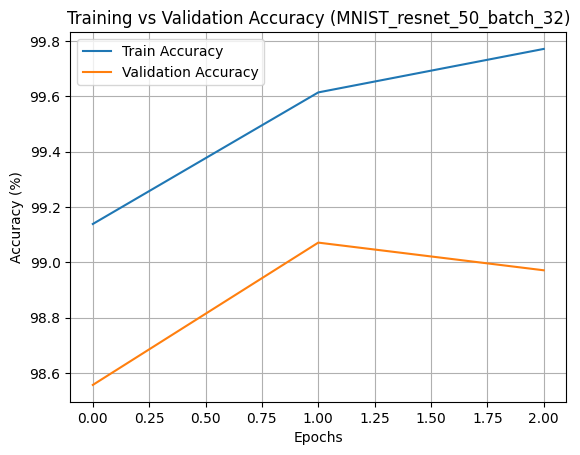

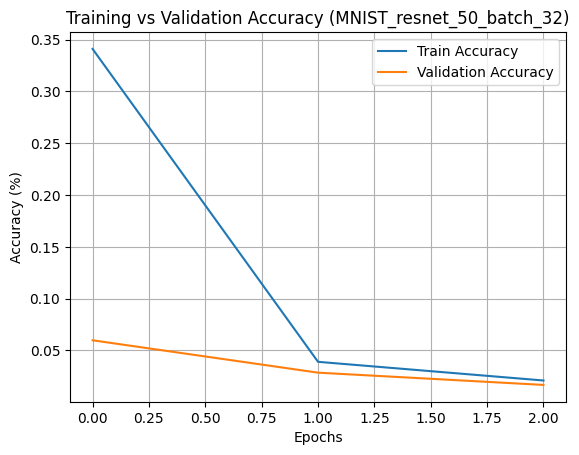

Train Accuracy: 99.77%
Validation Accuracy: 98.97%
Test Accuracy: 99.22%
Final Test Accuracy for ResNet-18: 99.22%


(99.22142857142858, 99.77142857142857, 98.97142857142858)

In [20]:
run_experiment("ResNet-18", 16, "SGD", 0.001, "MNIST",num_epochs=3)

In [45]:
run_experiment("ResNet-18", 16, "SGD", 0.0001, "MNIST",num_epochs=3,)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 1.4650, Val Acc 92.06%
Epoch 2: Loss 0.3174, Val Acc 96.29%
Epoch 3: Loss 0.1704, Val Acc 97.46%
Done! Model configuration saved to ResNet-18_BS16_SGD_LR0.0001.pth
Final Test Accuracy for ResNet-18: 97.46%


97.45714285714286

In [46]:
run_experiment("ResNet-18", 16, "Adam", 0.001, "MNIST",num_epochs=3)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.1408, Val Acc 97.71%
Epoch 2: Loss 0.0576, Val Acc 98.73%
Epoch 3: Loss 0.0417, Val Acc 99.00%
Done! Model configuration saved to ResNet-18_BS16_Adam_LR0.001.pth
Final Test Accuracy for ResNet-18: 98.79%


98.78571428571429

In [7]:
run_experiment("ResNet-18", 16, "Adam", 0.0001, "MNIST",num_epochs=3)

/tmp/ipykernel_55/579746265.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.1776, Val Acc 98.77%
Epoch 2: Loss 0.0467, Val Acc 99.10%
Epoch 3: Loss 0.0349, Val Acc 98.46%
Done! Model configuration saved to ResNet-18_BS16_Adam_LR0.0001.pth
Train Accuracy: 98.74%
Validation Accuracy: 98.46%
Test Accuracy: 98.24%


NameError: name 'plt' is not defined

In [47]:
run_experiment("ResNet-18", 32, "SGD", 0.001, "MNIST",num_epochs=3)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.5061, Val Acc 96.10%
Epoch 2: Loss 0.0760, Val Acc 98.51%
Epoch 3: Loss 0.0489, Val Acc 98.97%
Done! Model configuration saved to ResNet-18_BS32_SGD_LR0.001.pth
Final Test Accuracy for ResNet-18: 98.91%


98.91428571428571

In [57]:
run_experiment("ResNet-18", 32, "Adam", 0.0001, "MNIST",num_epochs=3)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.2129, Val Acc 98.61%
Epoch 2: Loss 0.0397, Val Acc 99.17%
Epoch 3: Loss 0.0307, Val Acc 98.99%
Done! Model configuration saved to ResNet-18_BS32_Adam_LR0.0001.pth
Final Test Accuracy for ResNet-18: 98.99%


98.98571428571428

In [58]:
run_experiment("ResNet-50", 16, "SGD", 0.001, "MNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.4635, Val Acc 97.40%
Epoch 2: Loss 0.0736, Val Acc 98.36%
Epoch 3: Loss 0.0432, Val Acc 98.29%
Epoch 4: Loss 0.0307, Val Acc 98.73%
Done! Model configuration saved to ResNet-50_BS16_SGD_LR0.001.pth
Final Test Accuracy for ResNet-50: 98.89%


98.89285714285714

In [59]:
run_experiment("ResNet-50", 16, "SGD", 0.0001, "MNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 1.6918, Val Acc 71.09%
Epoch 2: Loss 0.6404, Val Acc 93.47%
Epoch 3: Loss 0.2629, Val Acc 95.94%
Epoch 4: Loss 0.1677, Val Acc 96.86%
Done! Model configuration saved to ResNet-50_BS16_SGD_LR0.0001.pth
Final Test Accuracy for ResNet-50: 96.91%


96.90714285714286

In [60]:
run_experiment("ResNet-50", 16, "Adam", 0.001, "MNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.2191, Val Acc 95.03%
Epoch 2: Loss 0.0922, Val Acc 98.31%
Epoch 3: Loss 0.0663, Val Acc 98.61%
Epoch 4: Loss 0.0528, Val Acc 99.14%
Done! Model configuration saved to ResNet-50_BS16_Adam_LR0.001.pth
Final Test Accuracy for ResNet-50: 99.14%


99.13571428571429

In [61]:
run_experiment("ResNet-50", 16, "Adam", 0.0001, "MNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.2105, Val Acc 97.93%
Epoch 2: Loss 0.0613, Val Acc 98.24%
Epoch 3: Loss 0.0452, Val Acc 98.70%
Epoch 4: Loss 0.0378, Val Acc 98.89%
Done! Model configuration saved to ResNet-50_BS16_Adam_LR0.0001.pth
Final Test Accuracy for ResNet-50: 98.90%


98.9

In [62]:
run_experiment("ResNet-50", 32, "SGD", 0.001, "MNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.6942, Val Acc 97.23%
Epoch 2: Loss 0.0945, Val Acc 98.11%
Epoch 3: Loss 0.0537, Val Acc 98.66%
Epoch 4: Loss 0.0332, Val Acc 98.89%
Done! Model configuration saved to ResNet-50_BS32_SGD_LR0.001.pth
Final Test Accuracy for ResNet-50: 98.84%


98.84285714285714

In [63]:
run_experiment("ResNet-50", 32, "Adam", 0.0001, "MNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.2632, Val Acc 98.23%
Epoch 2: Loss 0.0526, Val Acc 97.03%
Epoch 3: Loss 0.0394, Val Acc 98.83%
Epoch 4: Loss 0.0319, Val Acc 98.74%
Done! Model configuration saved to ResNet-50_BS32_Adam_LR0.0001.pth
Final Test Accuracy for ResNet-50: 98.89%


98.88571428571429

In [65]:
run_experiment("ResNet-18", 16, "SGD", 0.001, "FashionMNIST", num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.6029, Val Acc 87.21%
Epoch 2: Loss 0.3207, Val Acc 88.61%
Epoch 3: Loss 0.2591, Val Acc 90.66%
Epoch 4: Loss 0.2186, Val Acc 91.77%
Done! Model configuration saved to ResNet-18_BS16_SGD_LR0.001.pth
Final Test Accuracy for ResNet-18: 91.18%


91.17857142857143

In [67]:
run_experiment("ResNet-18", 16, "SGD", 0.001, "FashionMNIST",num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.6063, Val Acc 87.74%
Epoch 2: Loss 0.3212, Val Acc 89.91%
Epoch 3: Loss 0.2563, Val Acc 89.91%
Epoch 4: Loss 0.2137, Val Acc 90.76%
Done! Model configuration saved to ResNet-18_BS16_SGD_LR0.001.pth
Final Test Accuracy for ResNet-18: 91.14%


91.13571428571429

/tmp/ipykernel_55/3478321569.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.4843, Val Acc 89.46%
Epoch 2: Loss 0.2474, Val Acc 91.99%
Epoch 3: Loss 0.1805, Val Acc 93.06%
Epoch 4: Loss 0.1201, Val Acc 93.24%
Done! Model configuration saved to ResNet-18_BS16_Adam_LR0.001.pth


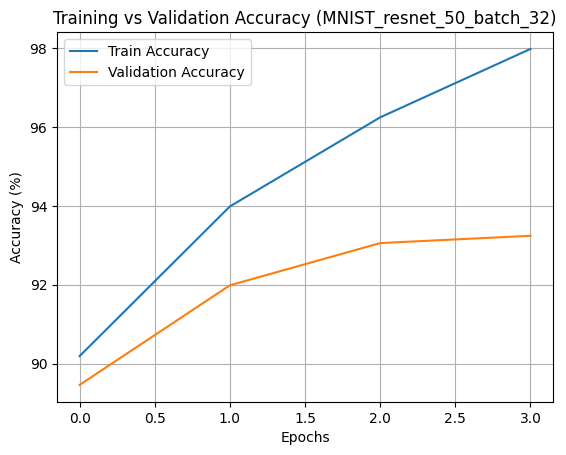

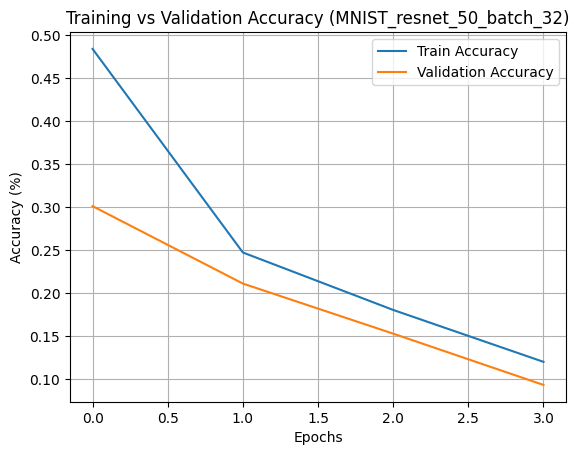

Train Accuracy: 97.99%
Validation Accuracy: 93.24%
Test Accuracy: 93.51%
Final Test Accuracy for ResNet-18: 93.51%


(93.51428571428572, 97.98571428571428, 93.24285714285715)

In [21]:
run_experiment("ResNet-18", 16, "Adam", 0.001, "FashionMNIST",num_epochs=4)

In [69]:
run_experiment("ResNet-18", 16, "Adam", 0.0001, "FashionMNIST", num_epochs=4)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.4969, Val Acc 88.19%
Epoch 2: Loss 0.2937, Val Acc 88.97%
Epoch 3: Loss 0.2405, Val Acc 91.53%
Epoch 4: Loss 0.2042, Val Acc 92.13%
Done! Model configuration saved to ResNet-18_BS16_Adam_LR0.001.pth
Final Test Accuracy for ResNet-18: 92.19%


92.19285714285714

In [70]:
run_experiment("ResNet-50", 16, "SGD", 0.001, "FashionMNIST",num_epochs=3)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.8285, Val Acc 83.99%
Epoch 2: Loss 0.4150, Val Acc 89.60%
Epoch 3: Loss 0.3218, Val Acc 89.11%
Done! Model configuration saved to ResNet-50_BS16_SGD_LR0.001.pth
Final Test Accuracy for ResNet-50: 89.11%


89.10714285714286

In [72]:
run_experiment("ResNet-50", 16, "Adam", 0.0001, "FashionMNIST",num_epochs=3)

/tmp/ipykernel_55/3869214237.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.5818, Val Acc 86.51%
Epoch 2: Loss 0.3334, Val Acc 89.39%
Epoch 3: Loss 0.2671, Val Acc 91.10%
Done! Model configuration saved to ResNet-50_BS16_Adam_LR0.0001.pth
Final Test Accuracy for ResNet-50: 91.10%


91.1

/tmp/ipykernel_55/3478321569.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.6380, Val Acc 88.41%
Epoch 2: Loss 0.2587, Val Acc 91.43%
Epoch 3: Loss 0.1920, Val Acc 91.83%
Done! Model configuration saved to ResNet-50_BS32_Adam_LR0.0001.pth


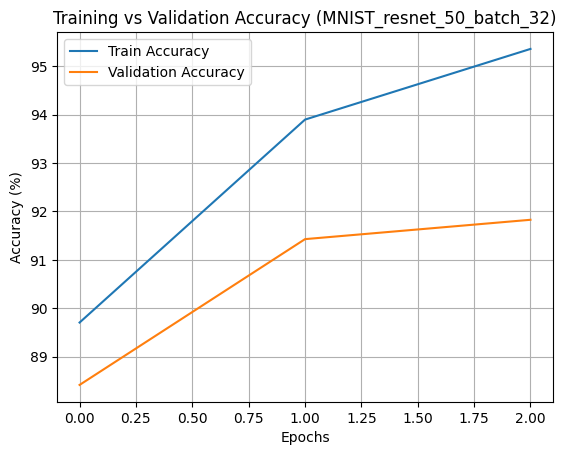

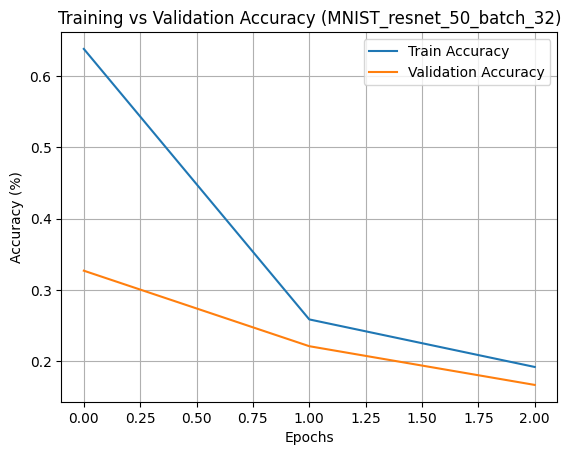

Train Accuracy: 95.36%
Validation Accuracy: 91.83%
Test Accuracy: 92.07%
Final Test Accuracy for ResNet-50: 92.07%


(92.07142857142857, 95.36122448979592, 91.82857142857142)

In [10]:
run_experiment("ResNet-50", 32, "Adam", 0.0001, "FashionMNIST",num_epochs=3)

/tmp/ipykernel_55/3478321569.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_55/1546015506.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1: Loss 0.9509, Val Acc 82.89%
Epoch 2: Loss 0.3555, Val Acc 89.63%
Epoch 3: Loss 0.2494, Val Acc 90.49%
Done! Model configuration saved to ResNet-50_BS32_SGD_LR0.001.pth


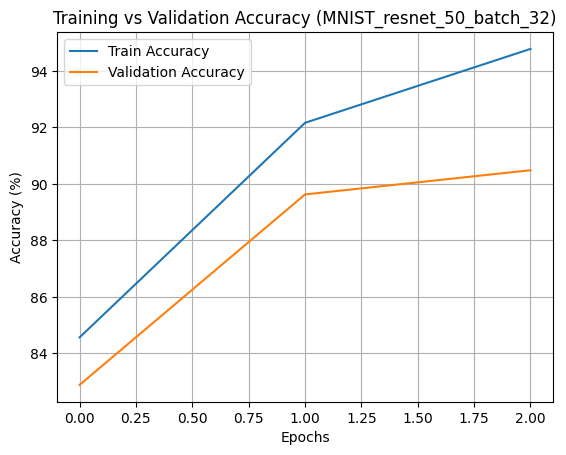

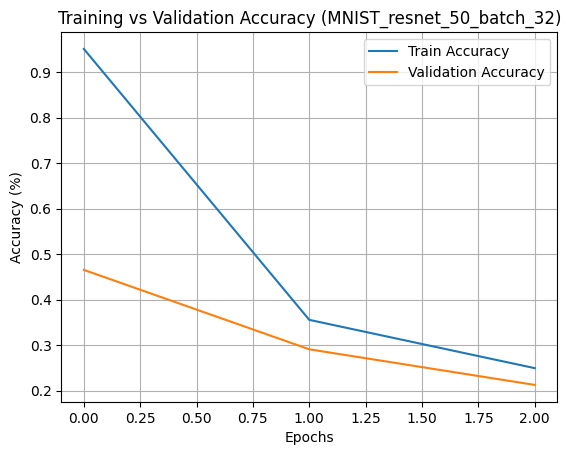

Train Accuracy: 94.78%
Validation Accuracy: 90.49%
Test Accuracy: 90.69%
Final Test Accuracy for ResNet-50: 90.69%


(90.69285714285714, 94.7795918367347, 90.48571428571428)

In [11]:
run_experiment("ResNet-50", 32, "SGD", 0.001, "FashionMNIST",num_epochs=3)

In [ ]:
run_experiment("ResNet-18", 32, "SGD", 0.001, "FashionMNIST",num_epochs=3)

In [ ]:
run_experiment("ResNet-18", 32, "Adam", 0.0001, "FashionMNIST",num_epochs=3)

In [73]:
pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=d7702d6da1f78f443de747cf23fe199544aa598afd6dc3de88835d61b0c8e9fb
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=693164c079be3ebb36b5909faa54f2c3e21b242c2f7c8568198a917d14d173e8
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install torch torchvision fvcore tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=4e5a4a50b6b9820bb5ff8409d0100f2142f3cc3603c73602e0e099bb231fa910
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=ea5b496f8eb3c36dbcbb90942af3adcc0c6267a82fbc98c6eb356022a62148c0
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath
Note: you may need to restart the kernel to use updated packages.


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
from tqdm import tqdm

# FLOPs
from fvcore.nn import FlopCountAnalysis

# Speed optimizations
torch.backends.cudnn.benchmark = True

from tqdm import tqdm

# FLOPs
from fvcore.nn import FlopCountAnalysis

# # Speed optimizations
# torch.backends.cudnn.benchmark = True

In [9]:
def get_device(use_gpu=True):
    if use_gpu and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


In [10]:
def get_dataloaders(batch_size=16):
    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_set = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )

    test_set = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    return train_loader, test_loader


In [11]:
def get_model(model_name):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(weights=None)
    # elif model_name == "resnet32":
    #     model = torchvision.models.resnet34(weights=None)  # commonly used as ResNet-32
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(weights=None)
    else:
        raise ValueError("Invalid model")

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model


In [13]:
def get_optimizer(optimizer_name, model, lr=0.001):
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("Invalid optimizer")


In [14]:
def calculate_flops(model, device):
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    flops = FlopCountAnalysis(model, dummy_input)
    return flops.total()


In [15]:
def train_model(model, train_loader, optimizer, device, epochs=2):
    model.train()
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler()

    start_time = time.time()

    for _ in range(epochs):
        for images, labels in tqdm(train_loader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=device.type=="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    torch.cuda.synchronize() if device.type == "cuda" else None
    total_time_ms = (time.time() - start_time) * 1000

    return total_time_ms


In [17]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [20]:
def run(
    compute="CPU",
    model_name="resnet18",
    optimizer_name="SGD",
    batch_size=16,
    lr=0.001
):
    device = get_device(use_gpu=(compute=="GPU"))
    train_loader, test_loader = get_dataloaders(batch_size)

    model = get_model(model_name).to(device)
    optimizer = get_optimizer(optimizer_name, model, lr)

    flops = calculate_flops(model, device)
    train_time = train_model(model, train_loader, optimizer, device)
    accuracy = evaluate_model(model, test_loader, device)

    return accuracy, train_time, flops


In [25]:
configs = [
    ("CPU", "resnet18", "SGD"),
    ("CPU", "resnet18", "Adam"),
    ("GPU", "resnet18", "SGD"),
    ("GPU", "resnet18", "Adam"),
]

for cfg in configs:
    acc, time_ms, flops = run(*cfg)
    print(cfg, f"Acc={acc:.2f}%", f"Time={time_ms:.1f}ms", f"FLOPs={flops:.2e}")


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet18', 'SGD') Acc=85.02% Time=327273.0ms FLOPs=1.83e+09


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet18', 'Adam') Acc=85.58% Time=532474.4ms FLOPs=1.83e+09


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet18', 'SGD') Acc=87.36% Time=56131.5ms FLOPs=1.83e+09


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet18', 'Adam') Acc=86.99% Time=51225.7ms FLOPs=1.83e+09


In [28]:
configs = [
    ("CPU", "resnet50", "SGD"),
    ("CPU", "resnet50", "Adam"),
    ("GPU", "resnet50", "SGD"),
    ("GPU", "resnet50", "Adam"),
]

for cfg in configs:
    acc, time_ms, flops = run(*cfg)
    print(cfg, f"Acc={acc:.2f}%", f"Time={time_ms:.1f}ms", f"FLOPs={flops:.2e}")


Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet50', 'SGD') Acc=82.54% Time=887577.1ms FLOPs=4.14e+09


Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet50', 'Adam') Acc=82.27% Time=1204471.9ms FLOPs=4.14e+09


Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet50', 'SGD') Acc=82.88% Time=104930.4ms FLOPs=4.14e+09


Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet50', 'Adam') Acc=80.90% Time=110957.5ms FLOPs=4.14e+09


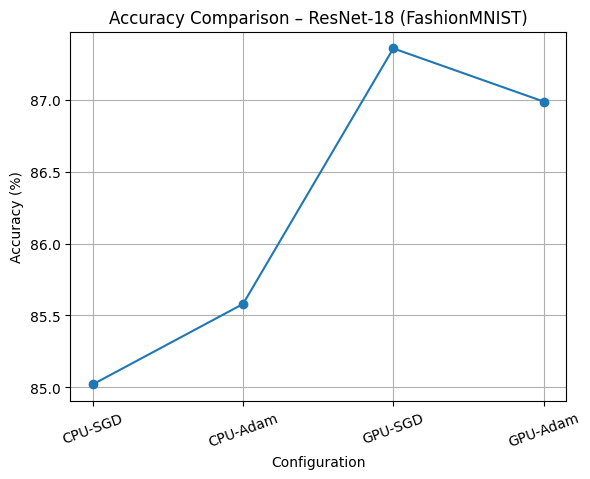

In [1]:
import matplotlib.pyplot as plt

labels = ["CPU-SGD", "CPU-Adam", "GPU-SGD", "GPU-Adam"]
accuracy = [85.02, 85.58, 87.36, 86.99]

x = range(len(labels))

plt.figure()
plt.plot(x, accuracy, marker='o')
plt.xticks(x, labels, rotation=20)
plt.xlabel("Configuration")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison – ResNet-18 (FashionMNIST)")
plt.grid(True)
plt.show()


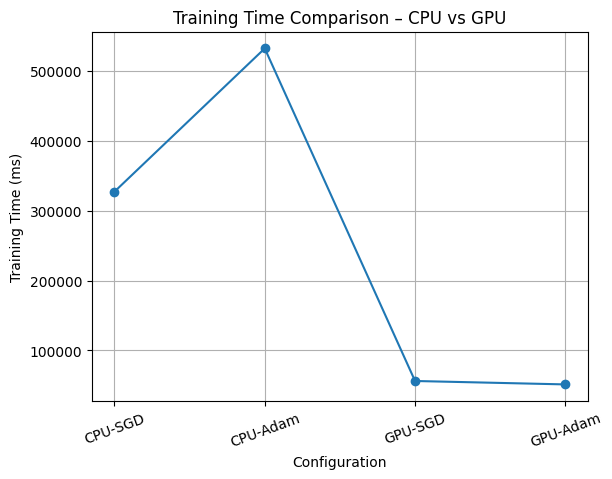

In [2]:
train_time = [327273.0, 532474.4, 56131.5, 51225.7]  # ms

plt.figure()
plt.plot(x, train_time, marker='o')
plt.xticks(x, labels, rotation=20)
plt.xlabel("Configuration")
plt.ylabel("Training Time (ms)")
plt.title("Training Time Comparison – CPU vs GPU")
plt.grid(True)
plt.show()
